# Tutorial 3 · An E/I balanced network

**What you'll learn.** How to assemble the canonical conductance-based
excitatory/inhibitory (COBA) network end to end, run it for a second of
biological time, and plot the population spike raster that reveals
asynchronous-irregular activity.

**Who it's for.** Readers comfortable with {doc}`02-synapse-and-projection`.
(Audience: simulation.)

This is the Vogels–Abbott (2005) balanced network as described in Brette et al.
(2007): 4000 leaky integrate-and-fire neurons (3200 excitatory, 800 inhibitory),
sparsely connected, with conductance-based exponential synapses. Excitation and
inhibition roughly cancel, so neurons fire irregularly at low rates rather than
locking together.

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import matplotlib.pyplot as plt

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Build the network

A single shared population `N` holds all 4000 neurons. Two projections feed back
onto it: an excitatory one (reversal potential 0 mV, fast 5 ms synapses) and an
inhibitory one (reversal potential −80 mV, slower 10 ms synapses). Each
projection uses one `AlignPostProj` — the postsynaptic-aligned state means the
whole network's synaptic memory is just `O(N)`.

In [2]:
class EINet(brainstate.nn.Module):
    def __init__(self):
        super().__init__()
        self.n_exc = 3200
        self.n_inh = 800
        self.num = self.n_exc + self.n_inh
        self.N = brainpy.state.LIFRef(
            self.num,
            V_rest=-60. * u.mV, V_th=-50. * u.mV, V_reset=-60. * u.mV,
            tau=20. * u.ms, tau_ref=5. * u.ms,
            V_initializer=braintools.init.Normal(-55., 2., unit=u.mV),
        )
        self.E = brainpy.state.AlignPostProj(
            comm=brainstate.nn.EventFixedProb(
                self.n_exc, self.num, conn_num=0.02, conn_weight=0.6 * u.mS),
            syn=brainpy.state.Expon.desc(self.num, tau=5. * u.ms),
            out=brainpy.state.COBA.desc(E=0. * u.mV),
            post=self.N,
        )
        self.I = brainpy.state.AlignPostProj(
            comm=brainstate.nn.EventFixedProb(
                self.n_inh, self.num, conn_num=0.02, conn_weight=6.7 * u.mS),
            syn=brainpy.state.Expon.desc(self.num, tau=10. * u.ms),
            out=brainpy.state.COBA.desc(E=-80. * u.mV),
            post=self.N,
        )

    def update(self, t, inp):
        with brainstate.environ.context(t=t):
            spk = self.N.get_spike() != 0.
            self.E(spk[:self.n_exc])      # excitatory neurons -> all
            self.I(spk[self.n_exc:])      # inhibitory neurons -> all
            self.N(inp)
            return self.N.get_spike()

## Simulate one second

We use `dt = 0.1 ms` and run for 1000 ms, injecting a constant background
current. `for_loop` compiles the whole 10000-step rollout once and returns the
stacked spike matrix; the optional progress bar reports compilation/run
progress.

In [3]:
net = EINet()
brainstate.nn.init_all_states(net)

with brainstate.environ.context(dt=0.1 * u.ms):
    times = u.math.arange(0. * u.ms, 1000. * u.ms, brainstate.environ.get_dt())
    spikes = brainstate.transform.for_loop(
        lambda t: net.update(t, 20. * u.mA), times,
        pbar=brainstate.transform.ProgressBar(10),
    )

print('spike matrix:', spikes.shape, '(time steps x neurons)')

  0%|          | 0/10000 [00:00<?, ?it/s]

spike matrix: (10000, 4000) (time steps x neurons)


## Raster plot

`u.math.where` over the spike matrix gives the (time-index, neuron-index) pairs
to scatter.

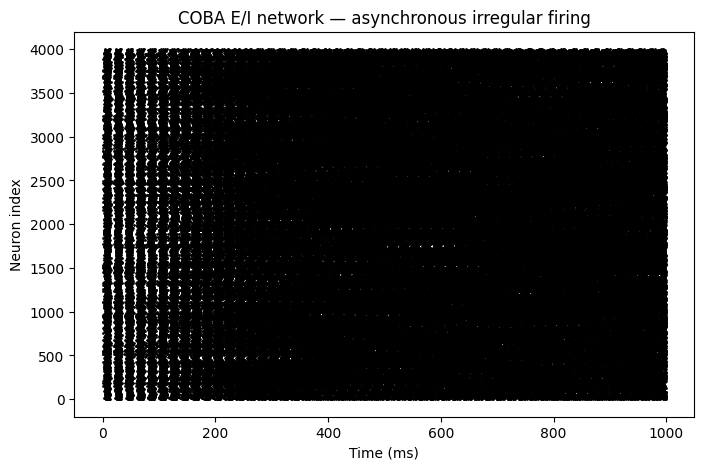

In [4]:
t_idx, n_idx = u.math.where(spikes)
plt.figure(figsize=(8, 5))
plt.scatter(times[t_idx].to_decimal(u.ms), n_idx, s=1, color='k')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('COBA E/I network — asynchronous irregular firing')
plt.show()

## See also

- {doc}`04-train-an-snn` — switch from simulating a fixed network to *training*
  one.
- {doc}`../howto/sim-coba-cuba-synapses` — the current-based (CUBA) counterpart
  of this network.
- {doc}`../howto/sim-reproduce-a-paper` — reproduce a published oscillation
  result.
- {doc}`/examples/brainpy-gallery` — more complete simulation scripts.